# Code to train a Vanilla Autoencoder
In this notebook we train a regular Autoencoder on the generated Gaussian dataset.
Please make sure to run "generated_data.ipynb" first to generate the dataset.

In [41]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# Loading the data
try:
    npzfile = np.load('generated_data.npz')
    x_train = torch.from_numpy(npzfile['x_train']).float()
    y_train = torch.from_numpy(npzfile['y_train']).float()
except FileNotFoundError:
    print("generated_data.npz not found. Please run the data generation script first.")
    raise

# Creating DataLoader
batch_size = 32

train_loader = DataLoader(
    TensorDataset(x_train),
    batch_size=batch_size,
    shuffle=True,
)

In [42]:
import torch.nn as nn

# Creating the model - Typical CNN autoencoder
class ConvAutoEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # --------------------------
        # Encoder (CNN → flatten)
        # --------------------------
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),   # 64 → 32
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),  # 32 → 16
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 16 → 8
            nn.ReLU(),
        )

        self.flatten = nn.Flatten()

        self.encoder_fc = nn.Sequential(
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        # --------------------------
        # Decoder (MLP → reshape → CNN)
        # --------------------------

        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * 8 * 8),
            nn.ReLU(),
        )

        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8 → 16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),   # 16 → 32
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),    # 32 → 64
        )

    def encode(self, x):
        z = self.encoder_cnn(x)
        z = self.flatten(z)
        z = self.encoder_fc(z)
        return z
    
    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(z.size(0), 32, 8, 8)
        x = self.decoder_cnn(x)
        return x
    
    def forward(self, x):
        B = x.shape[0]

        z = self.encode(x)

        x = self.decode(z)

        return x

In [43]:
# Setup for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvAutoEncoder(latent_dim=200).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_fn = nn.MSELoss()

In [44]:
# Training Loop
epochs = 200

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for (x,) in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat = model(x)

        loss = loss_fn(x_hat, x)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.6f} | "
    )

Epoch 001 | Train Loss: 0.984463 | 
Epoch 002 | Train Loss: 0.898273 | 
Epoch 003 | Train Loss: 0.624504 | 
Epoch 004 | Train Loss: 0.214266 | 
Epoch 005 | Train Loss: 0.098555 | 
Epoch 006 | Train Loss: 0.047825 | 
Epoch 007 | Train Loss: 0.025582 | 
Epoch 008 | Train Loss: 0.016932 | 
Epoch 009 | Train Loss: 0.011759 | 
Epoch 010 | Train Loss: 0.008453 | 
Epoch 011 | Train Loss: 0.006625 | 
Epoch 012 | Train Loss: 0.005607 | 
Epoch 013 | Train Loss: 0.004900 | 
Epoch 014 | Train Loss: 0.004588 | 
Epoch 015 | Train Loss: 0.003991 | 
Epoch 016 | Train Loss: 0.003842 | 
Epoch 017 | Train Loss: 0.004230 | 
Epoch 018 | Train Loss: 0.003169 | 
Epoch 019 | Train Loss: 0.002770 | 
Epoch 020 | Train Loss: 0.002990 | 
Epoch 021 | Train Loss: 0.002816 | 
Epoch 022 | Train Loss: 0.002580 | 
Epoch 023 | Train Loss: 0.002128 | 
Epoch 024 | Train Loss: 0.002098 | 
Epoch 025 | Train Loss: 0.002389 | 
Epoch 026 | Train Loss: 0.002398 | 
Epoch 027 | Train Loss: 0.002514 | 
Epoch 028 | Train Loss: 0.00

In [45]:
# Save the trained model
torch.save(model.state_dict(), "baseline.pth")

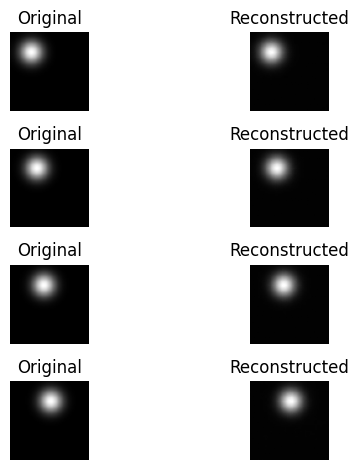

In [46]:
# Some sample reconstructions
import matplotlib.pyplot as plt

pred_train = model(x_train.to(device)).cpu().detach()

idxs = [1, 5, 10, 15]

for i, idx in enumerate(idxs):
    plt.subplot(4, 2, 2*i+1)
    plt.imshow(x_train[idx, 0].cpu().numpy(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(4, 2, 2*i+2)
    plt.imshow(pred_train[idx, 0].cpu().numpy(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

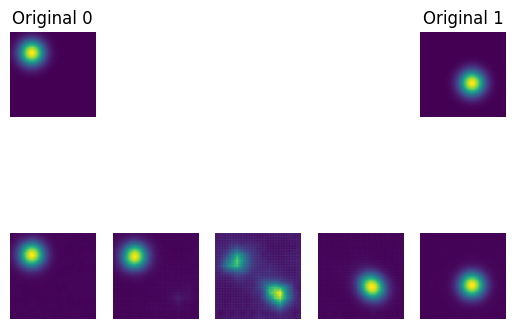

In [51]:
# Evaluating the quality of the latent space

# First test: Interpolation between two points in the latent space

idx_0 = 0
idx_1 = 600

lat_0 = model.encode(x_train[idx_0:idx_0+1].to(device)).cpu().detach()
lat_1 = model.encode(x_train[idx_1:idx_1+1].to(device)).cpu().detach()

lat_interp = torch.stack([lat_0 + (lat_1 - lat_0) * alpha for alpha in np.linspace(0, 1, 5)], dim=0)

res_interp = model.decode(lat_interp.to(device)).cpu().detach()

plt.subplot(2, res_interp.shape[0], 1)
plt.imshow(x_train[idx_0, 0].cpu().numpy())
plt.axis('off')
plt.title("Original 0")

plt.subplot(2, res_interp.shape[0], res_interp.shape[0])
plt.imshow(x_train[idx_1, 0].cpu().numpy())
plt.axis('off')
plt.title("Original 1")

for i in range(res_interp.shape[0]):
    plt.subplot(2, res_interp.shape[0], res_interp.shape[0] + i + 1)
    plt.imshow(res_interp[i, 0].cpu().numpy())
    plt.axis('off')

plt.savefig(f"interpolation_no_SVD.png")
plt.show()


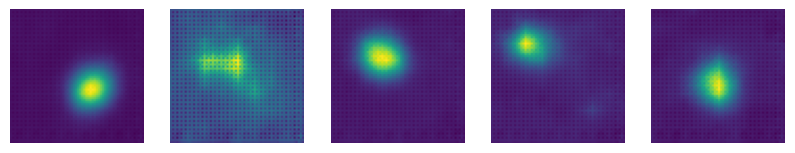

In [48]:
# Second test: Random sampling in the latent space

with torch.no_grad():
    lats = model.encode(x_train).cpu().detach()
    mins = lats.min(dim=0, keepdim=True).values
    maxs = lats.max(dim=0, keepdim=True).values
    random_lats = torch.rand(5, lats.shape[1]) * (maxs - mins) + mins
    random_samples = model.decode(random_lats.to(device)).cpu().detach()

plt.figure(figsize=(10, 2))
for i in range(random_samples.shape[0]):
    plt.subplot(1, random_samples.shape[0], i + 1)
    plt.imshow(random_samples[i, 0].cpu().numpy())
    plt.axis('off')

plt.savefig(f"random_sample_no_SVD.png")